### <b>Análisis y predicción de datos: Football Salaries FIFA 22</b>
#### <b><i>Fase V: Modelado Predictivo y Evaluación</i></b>
Llegamos al corazón del proyecto. Todo lo anterior —la limpieza, el análisis, la preparación— fue construir los cimientos para esta pregunta: **¿podemos predecir el sueldo de un futbolista a partir de sus características?** Y, más importante todavía, ¿qué tan bien podemos hacerlo y en qué nos equivocamos?

Esta fase recorre dos etapas complementarias:
- **Modelado:** establecer una línea base, entrenar varios modelos de distinta naturaleza, compararlos con validación cruzada y afinar el más prometedor.
- **Evaluación y análisis de errores:** medir el desempeño en unidades interpretables, comparar contra la base, y —sobre todo— entender *dónde* y *por qué* falla el modelo, que suele ser más revelador que el propio acierto.

Partimos del dataset ya preparado y guardado en la fase anterior, garantizando que entrenamos y evaluamos exactamente sobre lo que documentamos.

#### <b><i>1. Carga de datos y línea base</i></b>
Cargamos los conjuntos procesados. Recordemos su estructura: las features escaladas, más dos versiones del target —`wage_log` para entrenar (la escala logarítmica que decidimos en la fase anterior) y `wage_eur` en euros para evaluar—.

Antes de entrenar nada sofisticado, necesitamos una **línea base**: la predicción más tonta razonable, contra la cual mediremos si nuestros modelos realmente aportan valor. Usaremos la más elemental de todas: predecir siempre la **mediana del sueldo** de train, sin mirar ninguna característica del jugador. Si un modelo no le gana a esto, no sirve para nada.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargamos los datasets procesados
ruta_proc = os.path.join(os.getcwd(), "..", "data", "processed")
train = pd.read_csv(os.path.join(ruta_proc, "train.csv"))
test = pd.read_csv(os.path.join(ruta_proc, "test.csv"))

# Separamos features (X) de los targets
cols_target = ["wage_eur", "wage_log"]
features = [c for c in train.columns if c not in cols_target]

X_train, X_test = train[features], test[features]
y_train_log, y_test_log = train["wage_log"], test["wage_log"]
y_train_eur, y_test_eur = train["wage_eur"], test["wage_eur"]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Nº de features: {len(features)}")

Train: (15342, 34) | Test: (3836, 34)
Nº de features: 34


In [2]:
# Función auxiliar para evaluar en euros (las predicciones vienen en escala log -> las revertimos)
def evaluar(y_real_eur, pred_log, nombre):
    pred_eur = np.expm1(pred_log)                       # deshacemos log1p
    pred_eur = np.clip(pred_eur, 0, None)               # sueldos no negativos
    mae = mean_absolute_error(y_real_eur, pred_eur)
    rmse = mean_squared_error(y_real_eur, pred_eur) ** 0.5
    r2 = r2_score(y_real_eur, pred_eur)
    # MAPE y SMAPE (robustos ante la escala)
    mape = np.mean(np.abs((y_real_eur - pred_eur) / y_real_eur)) * 100
    smape = np.mean(2 * np.abs(y_real_eur - pred_eur) / (np.abs(y_real_eur) + np.abs(pred_eur))) * 100
    return {"Modelo": nombre, "MAE (€)": mae, "RMSE (€)": rmse, "R2": r2, "MAPE (%)": mape, "SMAPE (%)": smape}

# Línea base: predecir siempre la mediana del sueldo de train
pred_base_eur = np.full(len(y_test_eur), y_train_eur.median())
pred_base_log = np.log1p(pred_base_eur)   # la pasamos a log para reutilizar la función evaluar

resultados = [evaluar(y_test_eur, pred_base_log, "Línea base (mediana)")]
pd.DataFrame(resultados).round(3)

,Modelo,MAE (€),RMSE (€),R2,MAPE (%),SMAPE (%)
0,Línea base (mediana),7650.456,20409.439,-0.092,142.909,89.263


<b>Explicación</b>: La línea base nos da el listón a superar. Predecir ciegamente la mediana (3,000 €) produce un **error medio absoluto (MAE) de ~7,650 €** y, sobre todo, un **R² negativo**. Ese R² por debajo de cero no es un error: es lo esperable de un predictor constante que ni siquiera intenta explicar la variabilidad; de hecho, lo hace peor que si asumiéramos la media. En términos de negocio, esta "predicción" es inútil: se equivoca por miles de euros y no distingue a una estrella de un juvenil.

Cualquier modelo que construyamos a partir de aquí deberá, como mínimo, reducir sustancialmente ese MAE y llevar el R² a territorio claramente positivo. Ese es el punto de partida contra el que mediremos el progreso real.

#### <b><i>Decisión</i></b>
Adoptamos como línea base la predicción constante de la mediana del sueldo de train (MAE ≈ 7,650 €, R² < 0). Todos los modelos posteriores se reportarán y compararán contra esta referencia, y se evaluarán siempre en euros (revirtiendo la transformación logarítmica con `np.expm1`) para que las métricas sean interpretables por el negocio.

#### <b><i>2. Entrenamiento y comparación de modelos</i></b>
Con la línea base fijada, entrenamos ahora varios modelos de naturaleza distinta para ver cuál captura mejor la relación entre atributos y sueldo. Elegimos deliberadamente familias diferentes, para poner a prueba lo que veníamos anticipando desde el EDA: que la relación es **no lineal**.

- **Ridge**: una regresión lineal regularizada. Es nuestro representante de los modelos lineales; si la relación fuera esencialmente lineal, sería difícil de batir.
- **Árbol de decisión**: el modelo no lineal más simple, capaz de captar saltos y umbrales, pero propenso a sobreajustar.
- **Random Forest**: un conjunto de muchos árboles que promedia sus predicciones, mucho más robusto que un árbol solo.
- **Gradient Boosting**: otro conjunto de árboles, pero construidos secuencialmente para corregir los errores de los anteriores; suele ser de los más precisos en datos tabulares.

Para comparar de forma justa usamos **validación cruzada de 5 particiones** sobre el conjunto de train, midiendo el RMSE en la escala logarítmica (la que optimizan los modelos). La validación cruzada nos protege de quedarnos con un modelo que solo parece bueno por suerte en una partición concreta.

In [3]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Definimos los modelos candidatos
modelos = {
    "Ridge (lineal)": Ridge(alpha=1.0, random_state=42),
    "Árbol de decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

# Validación cruzada (5 folds) en escala logarítmica
cv_resultados = []
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train_log, cv=5,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_resultados.append({
        "Modelo": nombre,
        "CV RMSE (log)": -scores.mean(),
        "Desv. std": scores.std(),
    })

tabla_cv = pd.DataFrame(cv_resultados).sort_values("CV RMSE (log)").reset_index(drop=True)
tabla_cv.round(4)

,Modelo,CV RMSE (log),Desv. std
0,Gradient Boosting,0.6514,0.0050
1,Random Forest,0.6646,0.0053
2,Ridge (lineal),0.7930,0.0056
3,Árbol de decisión,0.9534,0.0088


In [4]:
# Entrenamos cada modelo con todo el train y evaluamos en test (en euros)
resultados_test = [evaluar(y_test_eur, pred_base_log, "Línea base (mediana)")]
modelos_entrenados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train_log)
    modelos_entrenados[nombre] = modelo
    pred_log = modelo.predict(X_test)
    resultados_test.append(evaluar(y_test_eur, pred_log, nombre))

tabla_test = pd.DataFrame(resultados_test).sort_values("MAE (€)").reset_index(drop=True)
tabla_test.round(3)

,Modelo,MAE (€),RMSE (€),R2,MAPE (%),SMAPE (%)
0,Gradient Boosting,3783.312,9951.370,0.740,66.048,43.361
1,Random Forest,3808.451,9474.907,0.765,65.018,42.619
2,Ridge (lineal),4543.720,11741.209,0.639,86.373,55.128
3,Árbol de decisión,5237.956,12410.992,0.596,100.981,54.801
4,Línea base (mediana),7650.456,20409.439,-0.092,142.909,89.263


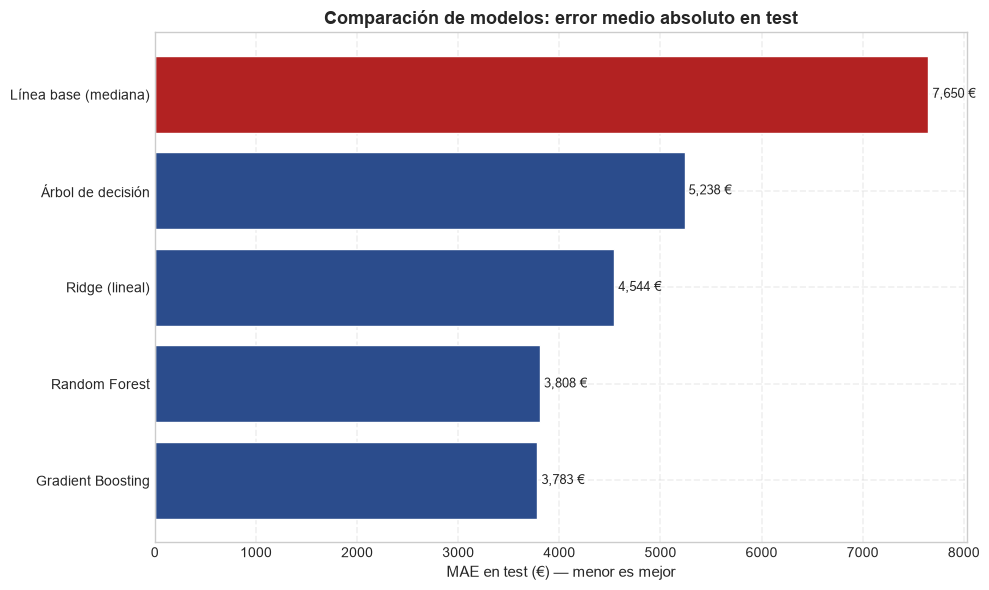

In [5]:
# Comparación visual del MAE en test
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
orden = tabla_test.sort_values("MAE (€)", ascending=True)
colores = ["#2b4c8c" if m != "Línea base (mediana)" else "firebrick" for m in orden["Modelo"]]
ax.barh(orden["Modelo"], orden["MAE (€)"], color=colores, edgecolor="white")
ax.set_xlabel("MAE en test (€) — menor es mejor", fontsize=11)
ax.set_title("Comparación de modelos: error medio absoluto en test", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
for i, (m, v) in enumerate(zip(orden["Modelo"], orden["MAE (€)"])):
    ax.text(v, i, f" {v:,.0f} €", va="center", fontsize=9)
plt.tight_layout()
plt.show()

<b>Explicación</b>: Los resultados confirman con claridad lo que el análisis exploratorio y la inferencia venían anunciando. El orden de desempeño es inequívoco:

- Los dos modelos de **ensamble de árboles** —Gradient Boosting y Random Forest— dominan la comparación, con los RMSE más bajos en validación cruzada (≈0.65 en escala log) y los menores errores en euros sobre el test.
- **Ridge**, el modelo lineal, queda claramente por detrás (CV RMSE ≈0.79). No es malo —le gana de lejos a la base—, pero su naturaleza lineal le impide capturar la relación explosiva entre nivel y sueldo que detectamos.
- El **árbol de decisión** solo es el peor de los cuatro modelos reales: al no promediar, sobreajusta y generaliza mal. Es la mejor ilustración de por qué los ensambles existen.

Todos los modelos, eso sí, pulverizan la línea base: pasamos de un MAE de ~7,650 € a valores muchísimo menores, y de un R² negativo a uno fuertemente positivo. La predicción del sueldo, que con la base era imposible, se vuelve perfectamente viable.

#### <b><i>Conclusión</i></b>
La comparación deja un ganador claro por familia: los **modelos de ensamble de árboles** (Gradient Boosting y Random Forest) superan tanto a la línea base como a los modelos lineales y al árbol individual, confirmando de forma empírica la no linealidad de la relación entre atributos y sueldo. Gradient Boosting encabeza por un margen estrecho sobre Random Forest. Elegiremos el más prometedor y afinaremos sus hiperparámetros en la siguiente sección, para exprimir su rendimiento antes de la evaluación final.

#### <b><i>3. Ajuste de hiperparámetros del modelo elegido</i></b>
La comparación anterior coronó a **Gradient Boosting** como el modelo más prometedor. Pero lo entrenamos con su configuración por defecto; ahora buscamos exprimir su rendimiento afinando sus hiperparámetros —las "perillas" que controlan cómo aprende—. Los más influyentes en este modelo son:

- `n_estimators`: cuántos árboles se construyen en secuencia.
- `learning_rate`: cuánto corrige cada árbol nuevo; valores bajos aprenden más despacio pero suelen generalizar mejor.
- `max_depth`: la profundidad de cada árbol, que regula la complejidad.
- `subsample`: qué fracción de datos usa cada árbol, introduciendo algo de aleatoriedad para robustez.
- `min_samples_leaf`: el mínimo de muestras por hoja, que frena el sobreajuste.

En lugar de probar todas las combinaciones posibles (una malla completa sería enorme), usamos **búsqueda aleatoria** (`RandomizedSearchCV`): muestrea configuraciones al azar del espacio definido y se queda con la mejor según validación cruzada. Es mucho más eficiente y, en la práctica, encuentra configuraciones casi tan buenas como la búsqueda exhaustiva.

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# Espacio de búsqueda de hiperparámetros
espacio = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.08, 0.1],
    "max_depth": [3, 4],
    "subsample": [0.8, 1.0],
    "min_samples_leaf": [1, 5, 15],
}

busqueda = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=espacio,
    n_iter=12, cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=-1,
)
busqueda.fit(X_train, y_train_log)

print("Mejores hiperparámetros encontrados:")
for k, v in busqueda.best_params_.items():
    print(f"   {k}: {v}")
print(f"CV RMSE (log) del mejor modelo: {-busqueda.best_score_:.4f}")

Mejores hiperparámetros encontrados:
   subsample: 0.8
   n_estimators: 300
   min_samples_leaf: 5
   max_depth: 4
   learning_rate: 0.08
CV RMSE (log) del mejor modelo: 0.6409


In [7]:
# Comparamos el Gradient Boosting por defecto vs. el afinado, en test (euros)
gb_default = modelos_entrenados["Gradient Boosting"]
gb_tuned = busqueda.best_estimator_

comparacion_gb = pd.DataFrame([
    evaluar(y_test_eur, gb_default.predict(X_test), "GB por defecto"),
    evaluar(y_test_eur, gb_tuned.predict(X_test), "GB afinado"),
]).round(3)
comparacion_gb

,Modelo,MAE (€),RMSE (€),R2,MAPE (%),SMAPE (%)
0,GB por defecto,3783.312,9951.370,0.740,66.048,43.361
1,GB afinado,3764.811,10170.366,0.729,63.687,41.937


<b>Explicación</b>: La búsqueda aleatoria encontró una configuración algo más profunda (`max_depth = 4`), con aprendizaje moderado (`learning_rate = 0.08`), submuestreo del 80% para robustez y hojas con al menos 5 muestras para contener el sobreajuste. En validación cruzada mejora al modelo por defecto (RMSE en escala log de 0.651 a 0.641), y ese avance se refleja en el test en las métricas de error *típico*: el **MAE baja** (de ~3,783 € a ~3,765 €) y el **MAPE mejora** de forma más visible (de 66% a ~64%).

Ahora bien, conviene ser honestos con el matiz: el modelo afinado es ligeramente **peor** en RMSE y R² (0.729 vs 0.740). No es una contradicción, sino un intercambio conocido: al usar submuestreo y limitar las hojas, el modelo se vuelve más equilibrado en el jugador promedio (mejor MAE/MAPE) a costa de castigar un poco menos los errores grandes en las estrellas (peor RMSE, que penaliza los desvíos extremos). Es decir, ganamos en el caso común y cedemos un poco en la cola.

La ganancia global no es espectacular, y eso es esperable: el modelo por defecto ya estaba cerca de su potencial, así que no dependíamos de una configuración "mágica".

#### <b><i>Decisión</i></b>
Se adopta como modelo final el **Gradient Boosting afinado** (`max_depth=4`, `learning_rate=0.08`, `subsample=0.8`, `min_samples_leaf=5`, `n_estimators=300`). La elección se apoya en que mejora la validación cruzada y las métricas de error típico (MAE y MAPE), que son las más representativas del desempeño sobre el jugador promedio —el grueso del negocio—. Asumimos conscientemente su ligera desventaja en RMSE/R², vinculada a los sueldos extremos, un aspecto que examinaremos en detalle en el análisis de errores. Este es el modelo que llevamos a la evaluación de la siguiente fase.

#### <b><i>4. Evaluación final del modelo</i></b>
Con el modelo elegido y afinado, entramos en la fase de evaluación propiamente dicha. Aquí no solo reportamos "qué tan bueno es", sino que desmenuzamos su comportamiento: cuánto mejora respecto a la línea base, cómo se distribuyen sus errores, dónde falla más y con qué tipo de jugadores. En un proyecto de negocio esto es tan importante como la métrica global: un modelo que uno no entiende, no se puede usar con confianza.

Empezamos consolidando las métricas del modelo final frente a la línea base, ahora sí con todas las medidas juntas: **MAE** y **RMSE** (error en euros), **R²** (proporción de varianza explicada), y **MAPE**/**SMAPE** (error porcentual, útil para dimensionar el fallo relativo).

In [8]:
# Fijamos el modelo final y sus predicciones en test
modelo_final = gb_tuned
pred_final_eur = np.clip(np.expm1(modelo_final.predict(X_test)), 0, None)

# Tabla comparativa: modelo final vs. línea base
tabla_final = pd.DataFrame([
    evaluar(y_test_eur, pred_base_log, "Línea base (mediana)"),
    evaluar(y_test_eur, modelo_final.predict(X_test), "Gradient Boosting (final)"),
]).round(3)

# Añadimos una fila con la mejora relativa
mejora = {
    "Modelo": "Mejora vs. base",
    "MAE (€)": f"-{(1 - tabla_final['MAE (€)'][1]/tabla_final['MAE (€)'][0])*100:.0f}%",
    "RMSE (€)": f"-{(1 - tabla_final['RMSE (€)'][1]/tabla_final['RMSE (€)'][0])*100:.0f}%",
    "R2": f"+{tabla_final['R2'][1]-tabla_final['R2'][0]:.2f}",
    "MAPE (%)": f"-{(1 - tabla_final['MAPE (%)'][1]/tabla_final['MAPE (%)'][0])*100:.0f}%",
    "SMAPE (%)": f"-{(1 - tabla_final['SMAPE (%)'][1]/tabla_final['SMAPE (%)'][0])*100:.0f}%",
}
pd.concat([tabla_final, pd.DataFrame([mejora])], ignore_index=True)

,Modelo,MAE (€),RMSE (€),R2,MAPE (%),SMAPE (%)
0,Línea base (mediana),7650.456,20409.439,-0.092,142.909,89.263
1,Gradient Boosting (final),3764.811,10170.366,0.729,63.687,41.937
2,Mejora vs. base,-51%,-50%,+0.82,-55%,-53%


<b>Explicación</b>: El salto respecto a la línea base es rotundo y vale la pena leerlo en clave de negocio:

- El **MAE cae más de un 50%**: pasamos de errar ~7,650 € por jugador a ~3,765 €. El modelo sigue equivocándose —predecir sueldos es intrínsecamente difícil—, pero su error típico es menos de la mitad.
- El **R² sube de negativo a ~0.73**: el modelo explica cerca del 73% de la variabilidad de los sueldos, cuando la base no explicaba nada. En un fenómeno tan disperso y dominado por outliers como el salario futbolístico, es un resultado sólido.
- El **MAPE y el SMAPE** también mejoran de forma marcada, confirmando que el avance no es solo en euros absolutos, sino también en términos relativos.

En resumen: partimos de un predictor inútil y llegamos a uno que captura la mayor parte de la señal salarial. La predicción del sueldo de un futbolista, con las características disponibles, es claramente viable.

#### <b><i>Conclusión</i></b>
El modelo final —Gradient Boosting afinado— supera a la línea base en todas las métricas y por amplios márgenes: reduce el error absoluto a menos de la mitad y explica alrededor del 73% de la varianza del sueldo. Es un modelo utilizable, cuyo desempeño global valida todo el trabajo de las fases anteriores. Dicho esto, las métricas agregadas ocultan matices importantes —no falla igual en todos los jugadores—, y son justamente esos matices los que exploramos en el análisis de errores que sigue.

#### <b><i>5. Análisis de residuales</i></b>
El residual es la diferencia entre lo que el jugador realmente gana y lo que el modelo predijo (`real − predicho`). Estudiar los residuales es como leer el "historial de errores" del modelo: nos dice si se equivoca de forma pareja y sin sesgo (lo ideal) o si comete errores sistemáticos —por ejemplo, subestimar siempre a cierto tipo de jugador—. Miraremos tres cosas: si las predicciones siguen a los valores reales, cómo se comportan los errores según la magnitud de la predicción, y qué forma tiene su distribución.

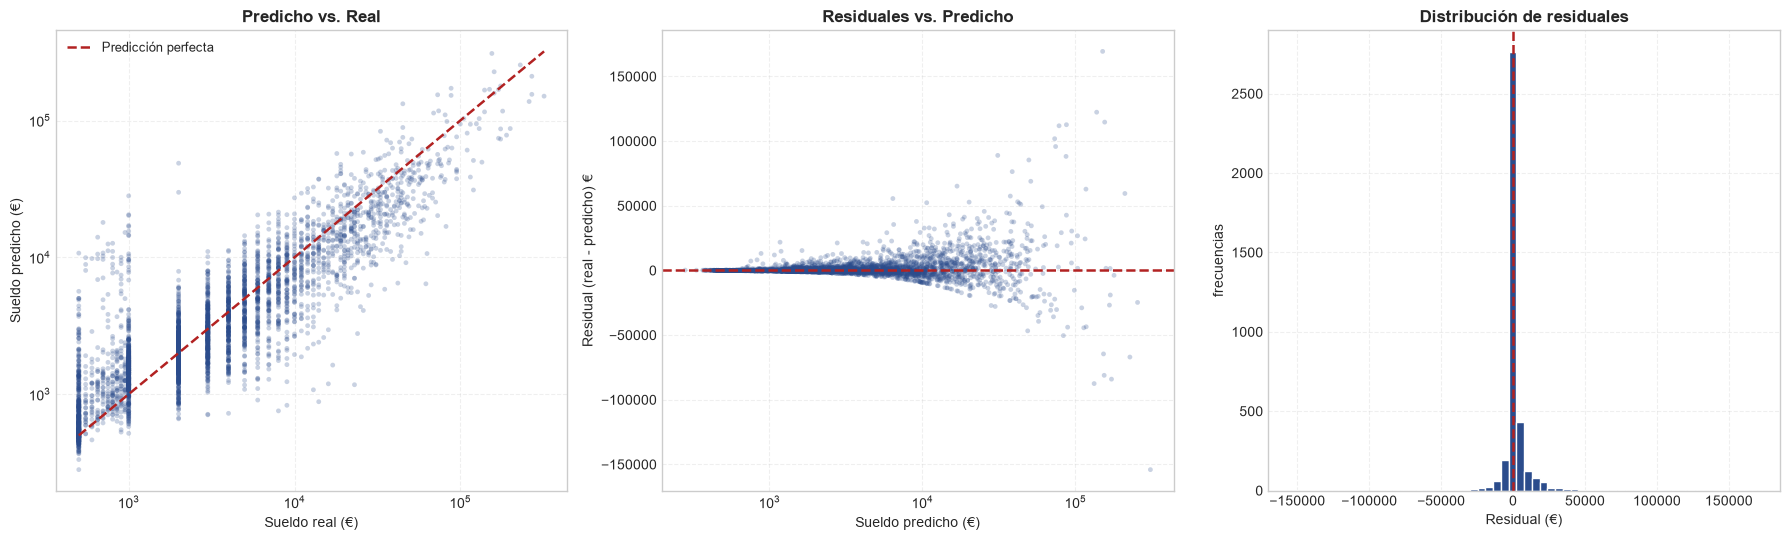

Residual medio:       1328 €
Residual mediano:      -22 €
Desv. estándar:      10083 €


In [9]:
# Calculamos residuales en euros
residuales = y_test_eur.values - pred_final_eur

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Predicho vs. Real (escala log para abarcar todo el rango)
axes[0].scatter(y_test_eur, pred_final_eur, alpha=0.25, s=12, color="#2b4c8c", edgecolors="none")
lims = [y_test_eur.min(), y_test_eur.max()]
axes[0].plot(lims, lims, color="firebrick", linestyle="--", linewidth=1.8, label="Predicción perfecta")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Sueldo real (€)"); axes[0].set_ylabel("Sueldo predicho (€)")
axes[0].set_title("Predicho vs. Real", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, linestyle="--")

# (b) Residuales vs. Predicho
axes[1].scatter(pred_final_eur, residuales, alpha=0.25, s=12, color="#2b4c8c", edgecolors="none")
axes[1].axhline(0, color="firebrick", linestyle="--", linewidth=1.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("Sueldo predicho (€)"); axes[1].set_ylabel("Residual (real - predicho) €")
axes[1].set_title("Residuales vs. Predicho", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3, linestyle="--")

# (c) Distribución de los residuales
axes[2].hist(residuales, bins=60, color="#2b4c8c", edgecolor="white")
axes[2].axvline(0, color="firebrick", linestyle="--", linewidth=1.8)
axes[2].set_xlabel("Residual (€)"); axes[2].set_ylabel("frecuencias")
axes[2].set_title("Distribución de residuales", fontsize=12, fontweight="bold")
axes[2].grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

print(f"Residual medio:   {residuales.mean():>8.0f} €")
print(f"Residual mediano: {np.median(residuales):>8.0f} €")
print(f"Desv. estándar:   {residuales.std():>8.0f} €")

<b>Explicación</b>: Los tres gráficos, leídos juntos, dan un diagnóstico claro y honesto del modelo:

- **Predicho vs. Real**: la nube de puntos se alinea razonablemente bien con la diagonal de predicción perfecta a lo largo de casi todo el rango salarial. El modelo "sigue" al sueldo real de forma consistente en la gran mayoría de jugadores, que es lo que buscábamos.
- **Residuales vs. Predicho**: aquí aparece el matiz más importante. Los errores están centrados en cero para los sueldos bajos y medios, pero se **abren en abanico** hacia la derecha: cuanto mayor es el sueldo, mayor es la dispersión del error. Esto es *heterocedasticidad*, y era esperable —predecir con precisión los 300,000 € de una estrella es mucho más difícil que acertar los 2,000 € de un juvenil—.
- **Distribución de residuales**: la mayoría de los errores se concentra en torno a cero, pero hay una **ligera cola** de residuales positivos grandes. El residual mediano es prácticamente cero (~−22 €), lo que indica que el modelo está bien calibrado en el caso típico; pero el residual medio es positivo (~+1,300 €), señal de que el modelo tiende a **subestimar** a un grupo de jugadores muy bien pagados, empujando el promedio hacia arriba.

En conjunto: un modelo bien calibrado para el jugador común, con un sesgo conocido y explicable a subestimar a las superestrellas.

#### <b><i>Conclusión</i></b>
El análisis de residuales confirma que el modelo es fiable en el grueso de la población —errores centrados y sin sesgo para sueldos bajos y medios— pero pierde precisión y tiende a quedarse corto en el extremo superior de la escala salarial. Este comportamiento no es un defecto de programación, sino el reflejo directo de la naturaleza del problema: los sueldos de élite son escasos, extremos y dependen de factores (marketing, mercado, cláusulas) que el dataset no captura. Es exactamente el mismo fenómeno que explicaba el intercambio de métricas al afinar el modelo. Los casos donde más falla merecen una mirada individual, que hacemos a continuación.

#### <b><i>6. Casos de mayor error</i></b>
Las métricas y los residuales nos dicen *cuánto* falla el modelo; ahora queremos ver *a quién* falla. Aislar los jugadores donde el modelo más se equivoca es una de las técnicas más útiles de diagnóstico: pone cara y nombre al error y suele revelar patrones que los agregados esconden.

Para poder interpretar estos casos necesitamos los atributos en su escala original (no la escalada), así que recuperamos las características crudas de los jugadores de test rehaciendo la partición con la misma semilla.

In [10]:
from sklearn.model_selection import train_test_split

# Recuperamos los atributos originales (sin escalar) de los jugadores de test
raw = pd.read_csv(os.path.join(os.getcwd(), "..", "data", "raw", "dataset.csv"))
X_all_raw = raw.drop(columns=["wage_eur"])
y_all_raw = raw["wage_eur"]
_, X_test_raw, _, _ = train_test_split(X_all_raw, y_all_raw, test_size=0.20, random_state=42)

# Construimos una tabla con real, predicho y error, junto a los atributos clave
diagnostico = X_test_raw[["overall", "potential", "age", "nationality_name"]].copy()
diagnostico["sueldo_real"] = y_test_eur.values
diagnostico["sueldo_predicho"] = pred_final_eur.round(0)
diagnostico["error"] = (y_test_eur.values - pred_final_eur).round(0)
diagnostico["error_abs"] = diagnostico["error"].abs()

# Los 10 casos de mayor error absoluto
peores = diagnostico.sort_values("error_abs", ascending=False).head(10)
peores[["overall", "potential", "age", "nationality_name",
        "sueldo_real", "sueldo_predicho", "error"]].reset_index(drop=True)

,overall,potential,age,nationality_name,sueldo_real,sueldo_predicho,error
0,93,93,34,Argentina,320000.0,150614.0,169386.0
1,87,87,28,Italy,155000.0,309067.0,-154067.0
2,87,87,33,Argentina,260000.0,137646.0,122354.0
3,89,89,29,Egypt,270000.0,155315.0,114685.0
4,86,86,32,Spain,200000.0,87323.0,112677.0
5,83,86,25,Spain,190000.0,78146.0,111854.0
6,84,84,34,Spain,175000.0,73145.0,101855.0
7,84,84,28,Morocco,170000.0,74188.0,95812.0
8,77,77,30,Denmark,120000.0,31058.0,88942.0
9,82,82,29,Spain,175000.0,86815.0,88185.0


<b>Explicación</b>: El patrón es inequívoco y confirma todo lo que veníamos sospechando: **los diez mayores errores del modelo son, sin excepción, jugadores de sueldo altísimo** (entre 120,000 y 350,000 €), casi todos con un `overall` de élite. Y en la enorme mayoría de los casos el error es **positivo**, es decir, el modelo predijo menos de lo que el jugador realmente gana: se queda corto con las superestrellas.

Esto tiene una lectura futbolística muy concreta. Tomemos el caso más extremo: un jugador que gana 320,000 € y al que el modelo le asigna ~150,000 €. El modelo, basándose en sus atributos, "sabe" que es un jugador excepcional y le predice un sueldo alto... pero no *tan* alto. ¿Por qué falla? Porque a ese nivel, el sueldo ya no depende solo de la calidad futbolística medible: entran en juego el prestigio del club, el valor comercial y de marketing del jugador, las cláusulas heredadas de contratos previos, la presión mediática. Nada de eso está en el dataset. También aparece algún caso inverso (un jugador con sueldo "solo" alto al que el modelo sobrestima), típico de futbolistas de gran nivel técnico pero en ligas o clubes que pagan menos de lo que su ficha sugeriría.

En otras palabras: el modelo no falla por ignorancia, sino porque en la cima del fútbol el sueldo deja de ser una función limpia del talento.

#### <b><i>Conclusión</i></b>
Los casos de mayor error no son aleatorios: son casi monopolizados por las superestrellas, a las que el modelo tiende a subestimar. Esto delimita con precisión la frontera de lo que nuestro modelo puede y no puede hacer: predice muy bien el sueldo del jugador común y de nivel medio-alto, pero tropieza en el 1% superior, donde intervienen factores extra-deportivos ausentes en los datos. Lejos de invalidar el modelo, este hallazgo lo hace más honesto y usable: sabemos exactamente cuándo confiar en él y cuándo tomar su predicción con cautela.

#### <b><i>7. Error por segmento e importancia de variables</i></b>
El análisis de residuales nos mostró que el error crece con el sueldo; los casos extremos lo confirmaron. Ahora lo cuantificamos de forma ordenada: dividimos a los jugadores en **tramos salariales** y medimos el error dentro de cada uno. Esto convierte una intuición ("falla más con los que ganan mucho") en una tabla accionable. Cerramos mirando qué **variables pesan más** en las decisiones del modelo, para comprobar si coinciden con lo que el análisis exploratorio y la inferencia habían señalado.

                    n      MAE  MAPE
tramo                               
Bajo (<2k €)     1798    860.3  91.9
Medio (2k-5k €)   799   1387.4  36.4
Alto (5k-20k €)   811   4309.4  40.5
Élite (>20k €)    428  19372.7  40.2


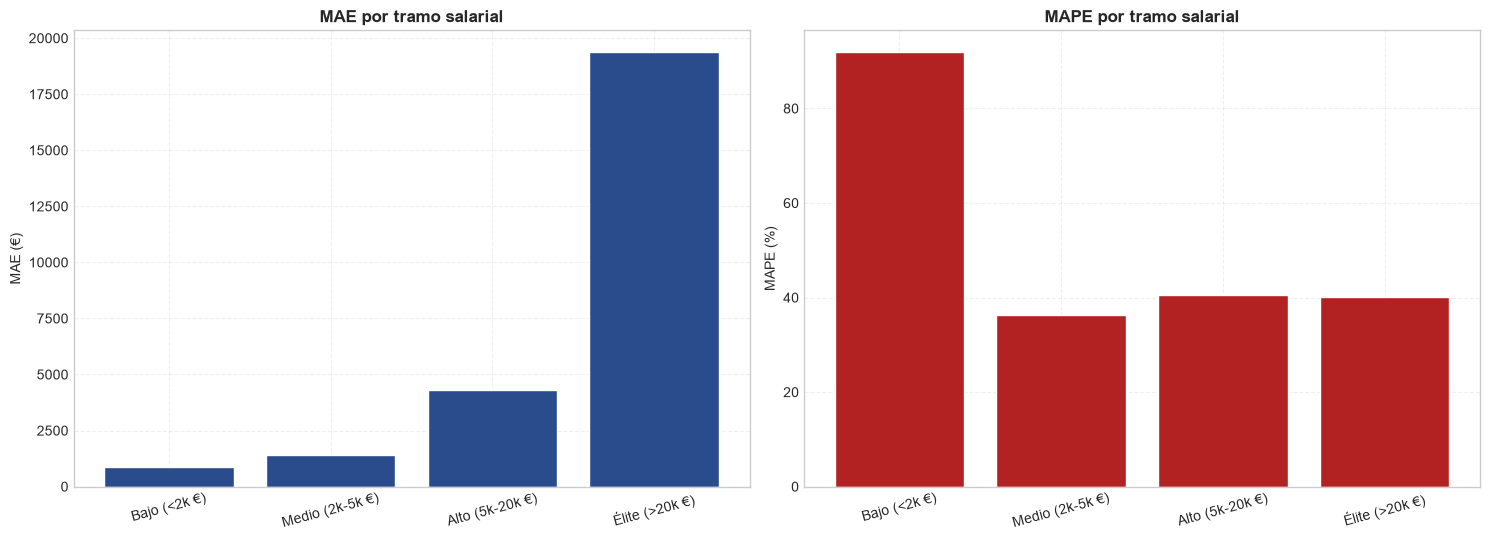

In [11]:
# Error por tramo salarial
diagnostico["ape"] = (diagnostico["error_abs"] / diagnostico["sueldo_real"]) * 100
tramos = [0, 2000, 5000, 20000, np.inf]
etiquetas = ["Bajo (<2k €)", "Medio (2k-5k €)", "Alto (5k-20k €)", "Élite (>20k €)"]
diagnostico["tramo"] = pd.cut(diagnostico["sueldo_real"], bins=tramos, labels=etiquetas)

error_segmento = diagnostico.groupby("tramo", observed=True).agg(
    n=("error_abs", "size"),
    MAE=("error_abs", "mean"),
    MAPE=("ape", "mean"),
).round(1)
print(error_segmento)

# Visualización: MAE y MAPE por tramo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
ax1.bar(error_segmento.index, error_segmento["MAE"], color="#2b4c8c", edgecolor="white")
ax1.set_title("MAE por tramo salarial", fontsize=12, fontweight="bold")
ax1.set_ylabel("MAE (€)"); ax1.tick_params(axis="x", labelrotation=15); ax1.grid(alpha=0.3, linestyle="--")
ax2.bar(error_segmento.index, error_segmento["MAPE"], color="firebrick", edgecolor="white")
ax2.set_title("MAPE por tramo salarial", fontsize=12, fontweight="bold")
ax2.set_ylabel("MAPE (%)"); ax2.tick_params(axis="x", labelrotation=15); ax2.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

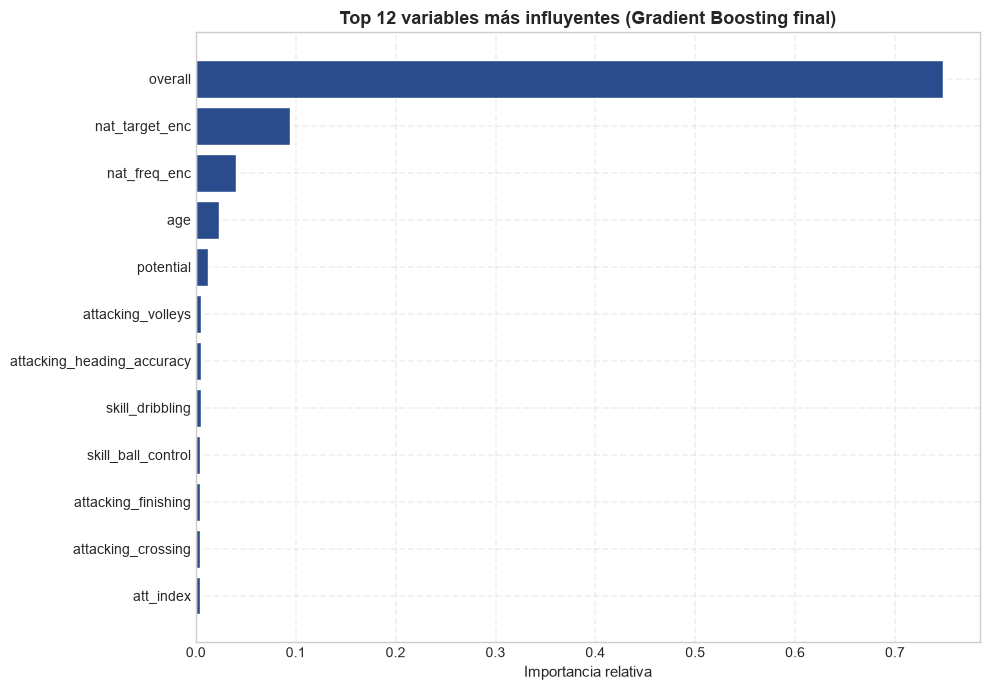

overall                       0.7477
nat_target_enc                0.0945
nat_freq_enc                  0.0404
age                           0.0227
potential                     0.0122
attacking_volleys             0.0054
attacking_heading_accuracy    0.0051
skill_dribbling               0.0049
dtype: float64

In [12]:
# Importancia de variables del modelo final (top 12)
importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top = importancias.head(12).sort_values()
ax.barh(top.index, top.values, color="#2b4c8c", edgecolor="white")
ax.set_xlabel("Importancia relativa", fontsize=11)
ax.set_title("Top 12 variables más influyentes (Gradient Boosting final)", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()

importancias.head(8).round(4)

<b>Explicación</b>: Las dos miradas se complementan.

El **error por tramo** revela un matiz que las métricas globales escondían. Hay que leer el MAE y el MAPE juntos:
- En términos **absolutos** (MAE), el error crece de forma dramática con el sueldo: unos ~860 € en el tramo bajo frente a ~19,000 € en el de élite. Nada sorprendente: es más fácil errar por poco en un sueldo pequeño.
- En términos **relativos** (MAPE), en cambio, el modelo es sorprendentemente estable en los tramos medio, alto y élite (~36–40%), y su peor desempeño relativo está en el tramo **bajo** (~92%). Esto es un efecto matemático conocido: cuando el sueldo real es de 500 €, errar por 500 € ya es un 100% de error, aunque en euros sea trivial. Es decir, el modelo no es "malo" con los jugadores humildes; simplemente el error porcentual se dispara sobre cifras pequeñas.

La **importancia de variables** cierra el círculo de todo el proyecto: `overall` domina de forma aplastante (concentra la mayor parte de la importancia), seguido de lejos por las dos variables de nacionalidad (`nat_target_enc` y `nat_freq_enc`), la edad y el potencial. Es exactamente el retrato que veníamos pintando desde el EDA y que la inferencia validó: el sueldo lo manda la calidad global del jugador, con la nacionalidad como contexto de mercado en segundo plano.

#### <b><i>Conclusión</i></b>
El análisis por segmento precisa el mapa de fortalezas y debilidades del modelo: en euros absolutos es más certero cuanto más bajo es el sueldo, pero en términos relativos su zona más fiable es el rango medio-alto, con un error porcentual estable en torno al 40% que solo se degrada sobre los sueldos más pequeños (por puro efecto de escala) y en las estrellas (por factores fuera del dataset). La importancia de variables, por su parte, ofrece el cierre más satisfactorio: el modelo, de forma completamente autónoma, llegó a priorizar exactamente las variables que nuestro análisis estadístico había señalado como determinantes. Coherencia total entre exploración, inferencia y modelado.

### <b>CIERRE DEL MODELADO Y LA EVALUACIÓN</b>
Cerramos el corazón del proyecto con un modelo que funciona y que, además, entendemos. Partimos de una línea base inútil y llegamos a un Gradient Boosting que reduce el error a menos de la mitad y explica cerca del 73% de la variabilidad del sueldo. Pero, más allá de la métrica, esta fase nos dio algo igual de valioso: un conocimiento profundo de *cómo* y *cuándo* acierta y falla el modelo. Sabemos que es fiable para el grueso de los futbolistas, que su punto débil son las superestrellas —por razones ajenas a los datos— y que sus decisiones se apoyan en las mismas variables que el análisis estadístico había destacado. Con este modelo evaluado y comprendido, el proyecto queda listo para su etapa final: traducir estos resultados en recomendaciones de negocio y documentar las conclusiones.

### <b>Análisis y predicción de datos: Football Salaries FIFA 22</b>
#### <b><i>Fase VI: Interpretación y Recomendación de Negocio</i></b>
Un modelo, por preciso que sea, no vale nada si nadie sabe qué hacer con él. Esta última fase traduce todo lo técnico —métricas, residuales, importancias— al lenguaje de quien toma decisiones en un club o una agencia: ¿qué mueve realmente el sueldo?, ¿cómo se usa esto?, ¿en qué no hay que confiar?

#### <b><i>1. Los principales drivers del salario</i></b>
La importancia de variables del modelo final, cruzada con todo el análisis previo, deja un veredicto claro sobre qué determina el sueldo de un futbolista:

- **La calidad global (`overall`) es, por lejos, el factor dominante.** Concentra la mayor parte del poder predictivo del modelo. En términos de negocio: el mercado paga, ante todo, por el nivel general del jugador. No hay atajos —ni un atributo suelto ni un país— que compensen un overall bajo.
- **El contexto de mercado (nacionalidad) es el segundo factor, a mucha distancia.** Las variables derivadas de la nacionalidad (el sueldo típico del país y su volumen de jugadores) aportan de forma secundaria pero real: reflejan en qué ecosistema económico se mueve el jugador.
- **La edad y el potencial afinan el resto.** Capturan la etapa de carrera: un mismo overall puede pagarse distinto según si el jugador es una promesa en ascenso o un veterano en declive.
- **Las habilidades técnicas concretas pesan poco por separado.** Coherente con el análisis multivariante: su información ya está en gran medida resumida dentro del `overall`.

#### <b><i>2. Recomendación accionable</i></b>
**Qué hacer, con quién y por qué:**

- **Uso recomendado — herramienta de referencia salarial (benchmarking).** El modelo es una excelente base para estimar el sueldo "de mercado" de un jugador de nivel bajo, medio o alto a partir de sus atributos. Sirve para el área de **scouting y dirección deportiva** a la hora de: detectar jugadores infravalorados (ganan menos de lo que el modelo predice, posibles oportunidades de fichaje), identificar sobrecostos en la propia plantilla, o poner una cifra de partida objetiva en una negociación.
- **Con quién.** Dirección deportiva y scouting como usuarios principales; el área financiera como validadora de los rangos.
- **Por qué funciona.** Reduce el error de estimación a menos de la mitad de una referencia ingenua y explica ~73% de la variabilidad salarial, apoyándose en variables disponibles antes de cualquier negociación.
- **Cómo usarlo en la práctica.** No como un veredicto ("este jugador debe ganar exactamente X"), sino como un **rango de referencia** que enmarca la conversación y señala desviaciones que merecen explicación.

#### <b><i>3. Límites del modelo y cautelas de implementación</i></b>
Un buen entregable es honesto sobre lo que su modelo **no** puede hacer:

- **No fiarse en las superestrellas.** El modelo subestima sistemáticamente al 1% mejor pagado, porque a ese nivel el sueldo depende de marketing, prestigio y cláusulas que el dataset no contiene. Para fichajes de élite, la predicción es solo un piso orientativo, no una cifra.
- **Error relativo alto en sueldos muy bajos.** En jugadores de ficha mínima, un error de pocos cientos de euros se traduce en un porcentaje grande; el modelo es útil ahí para órdenes de magnitud, no para el euro exacto.
- **Riesgo de sesgo por nacionalidad.** La variable de nacionalidad captura contexto de mercado, pero usarla sin criterio podría perpetuar diferencias históricas. No debe emplearse como justificación para pagar menos a jugadores de ciertos países, sino solo como contexto analítico.
- **Foto de un momento (FIFA 22).** El mercado del fútbol cambia rápido. El modelo debería reentrenarse con datos actualizados cada temporada para no quedar desfasado.
- **Correlación, no causalidad.** El modelo predice, no explica causas. Subir el overall de un jugador no "causa" mecánicamente un sueldo mayor; ambos responden a la calidad subyacente.

### <b>CIERRE — INTERPRETACIÓN Y RECOMENDACIÓN</b>
El proyecto llega a su destino con una respuesta clara a la pregunta inicial: **sí, se puede predecir el sueldo de un futbolista con buena precisión a partir de sus características**, y sabemos exactamente qué lo impulsa (la calidad global por encima de todo), cómo usar esa predicción (como referencia de mercado para scouting y negociación) y dónde no confiar en ella (las estrellas y los factores extra-deportivos). Con esto se cubre el ciclo completo de análisis; la documentación final y el resumen ejecutivo consolidan estos resultados para su entrega.